# Figure 6.4-5 &mdash; Temperature&ndash;entropy diagram for oxygen (Peng&ndash;Robinson EOS)

This notebook recreates **Figure 6.4-5** of Illustration 6.4-1, *Making of a
Thermodynamic Properties Chart*. It plots isobars of oxygen in the
$T$&ndash;$\underline{S}$ plane from the Peng&ndash;Robinson equation of state,
with the vapor&ndash;liquid two-phase region.

The entropy at each $(T, P)$ is the ideal-gas entropy plus the **entropy
departure** (SIS Eq. 6.4-30):

$$ \underline{S}(T,P) = \underline{S}^{\mathrm{IG}}(T,P)
   + \left[\underline{S}(T,P) - \underline{S}^{\mathrm{IG}}(T,P)\right] $$

with the reference state (as in the book) the ideal gas at $25\,^{\circ}$C and
1 bar, where $\underline{S} = 0$. Inside the two-phase region an isobar is
horizontal (constant $T$ and $P$), running from saturated liquid to saturated
vapor; those tie lines and the envelope use the fugacity condition of Chapter 7.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst  
July 2026

In [ ]:
# --- Colab bootstrap -------------------------------------------------------
# The axis labels below use the book's molar underbar, \underline{V}. With no LaTeX
# installed, matplotlib renders math with its own mathtext engine, which only learned
# \underline in 3.11 -- and Colab still ships 3.10. This upgrades it there, and does
# nothing at all on a machine that already has 3.11 or newer.
#
# ON COLAB THIS NEEDS A SESSION RESTART. Colab imports matplotlib as the session
# starts, so pip can replace the files on disk but not the module already loaded in
# memory: without a restart the kernel keeps running 3.10 and the labels still fail.
# One click, once per session. The cell prints the instruction when it applies.
import sys
from importlib.metadata import version

if tuple(map(int, version("matplotlib").split(".")[:2])) < (3, 11):
    !pip install -q "matplotlib>=3.11"
    if "matplotlib" in sys.modules:
        print("\n" + "=" * 72)
        print("  matplotlib was upgraded so this notebook can draw the book's notation.")
        print("  RESTART NOW:   Runtime > Restart session,   then Run all.")
        print("  Colab only, once per session. Without it the next figure will fail.")
        print("=" * 72 + "\n")
# ---------------------------------------------------------------------------

## Generalized Peng&ndash;Robinson equation of state

$$ P = \frac{RT}{\underline{V}-b} - \frac{a(T)}{\underline{V}(\underline{V}+b) + b(\underline{V}-b)} \tag{Eq. 6.4-2}$$

with $b$, $a(T)$, $\alpha(T)$, and $\kappa$ from Eqs. 6.7-1 to 6.7-4; the molar
volume follows from the cubic in $Z=P\underline{V}/RT$ (Table 6.4-3).

In [1]:
"""Generalized Peng-Robinson EOS for oxygen (SI units: K, Pa, m^3/mol)."""
import numpy as np
from scipy import constants
from numpy.polynomial import Polynomial

R = constants.R

# Oxygen (SIS Table 6.6-1); omega = 0.021 gives kappa = 0.4069
Pc = 5.046e6
Tc = 154.6
omega = 0.021
kappa = 0.37464 + 1.54226 * omega - 0.26992 * omega**2


def calc_b(Pc, Tc):
    return 0.07780 * R * Tc / Pc


def calc_a(T, Pc, Tc, omega):
    sqrtalpha = 1 + kappa * (1 - np.sqrt(T / Tc))
    return 0.45724 * R**2 * Tc**2 / Pc * sqrtalpha**2


def calc_dadT(T, Pc, Tc, omega):
    sqrtalpha = 1 + kappa * (1 - np.sqrt(T / Tc))
    return -0.45724 * R**2 * Tc**2 / Pc * kappa * sqrtalpha / np.sqrt(T * Tc)


def PR_pressure(V, T, Pc, Tc, omega):
    a, b = calc_a(T, Pc, Tc, omega), calc_b(Pc, Tc)
    return R * T / (V - b) - a / (V * (V + b) + b * (V - b))


def PR_roots_Z(P, T, Pc, Tc, omega):
    a, b = calc_a(T, Pc, Tc, omega), calc_b(Pc, Tc)
    A = a * P / R**2 / T**2
    B = b * P / R / T
    alpha = -1 + B
    beta = A - 3 * B**2 - 2 * B
    gamma = -A * B + B**2 + B**3
    roots = Polynomial([gamma, beta, alpha, 1]).roots()
    tol = 1e-6 * np.maximum(1.0, np.abs(roots.real))
    return np.sort(roots.real[np.abs(roots.imag) < tol]), A, B


def Z_phase(P, T, phase):
    Z, A, B = PR_roots_Z(P, T, Pc, Tc, omega)
    return (Z.max() if phase == "vapor" else Z.min()), A, B


print(f"oxygen: Tc = {Tc} K, Pc = {Pc/1e5:.2f} bar, kappa = {kappa:.4f}")


oxygen: Tc = 154.6 K, Pc = 50.46 bar, kappa = 0.4069


## Entropy: ideal-gas part + departure

The **entropy departure** for the Peng&ndash;Robinson equation of state is
(SIS Eq. 6.4-30)

$$ \underline{S} - \underline{S}^{\mathrm{IG}}
 = R\ln(Z-B) + \frac{1}{2\sqrt{2}\,b}\,\frac{da}{dT}\,
   \ln\!\left[\frac{Z+(1+\sqrt{2})B}{Z+(1-\sqrt{2})B}\right] $$

The ideal-gas entropy carries both a temperature and a pressure term,

$$ \underline{S}^{\mathrm{IG}}(T,P)
 = \int_{T_0}^{T}\frac{C_P^{\mathrm{IG}}}{T}\,dT - R\ln\frac{P}{P_0} $$

with $C_P^{\mathrm{IG}} = a_C + b_C T + c_C T^2 + d_C T^3$ and the reference the
ideal gas at $T_0 = 25\,^{\circ}$C, $P_0 = 1$ bar, where $\underline{S} = 0$.

In [2]:
SQRT2 = np.sqrt(2.0)

# Ideal-gas Cp coefficients for oxygen, Appendix A.II, J/(mol K).
# The book's own coefficients -- not the Reid-Prausnitz-Poling set in
# code/data/pure_property.csv, which does not reproduce Illustration 6.4-1.
cA, cB, cC, cD = 30.171, -1.293e-2, 4.236e-5, -2.5828e-8
# Appendix A.II CRYOGENIC range row (100-700 K), new in the 6e. NOT the familiar
# 273-1800 K row (25.460, 1.519e-2, -0.715e-5, 1.311e-9): this figure runs down to
# -183 C = 90 K, and extrapolating that row below 273 K costs 67 J/mol in H and
# 0.32 J/(mol K) in S at 173 K. See code/thermo/data.py and
# code/ch3/Heat_capacity_range_of_validity.ipynb.
T_REF, P_REF = 298.15, 1e5   # ideal gas at 25 C, 1 bar -> S = 0


def log_term(Z, B):
    return np.log((Z + (1 + SQRT2) * B) / (Z + (1 - SQRT2) * B))


def departure_S(P, T, phase):
    """S - S_ideal-gas at (T, P), J/(mol K) (SIS Eq. 6.4-30)."""
    Z, A, B = Z_phase(P, T, phase)
    b = calc_b(Pc, Tc)
    dadT = calc_dadT(T, Pc, Tc, omega)
    return R * np.log(Z - B) + dadT / (2 * SQRT2 * b) * log_term(Z, B)


def S_ideal(T, P):
    """Ideal-gas entropy relative to (T_REF, P_REF), J/(mol K)."""
    return (cA * np.log(T / T_REF) + cB * (T - T_REF)
            + cC / 2 * (T**2 - T_REF**2) + cD / 3 * (T**3 - T_REF**3)
            - R * np.log(P / P_REF))


def entropy(P, T, phase):
    """Molar entropy (J/mol K) relative to the ideal gas at 25 C, 1 bar."""
    return S_ideal(T, P) + departure_S(P, T, phase)


print(f"S(25 C, 1 bar) = {entropy(P_REF, T_REF, 'vapor'):.3f} J/(mol K)  (ref: 0)")


S(25 C, 1 bar) = -0.024 J/(mol K)  (ref: 0)


## Saturation temperature and the two-phase envelope

For $T < T_c$ the saturation pressure is found by bracketing the equal-fugacity
condition between the isotherm's spinodal pressures and solving with bisection.
We build the envelope as a table of $(T, P^{\mathrm{sat}}, \underline{S}^L,
\underline{S}^V)$; the saturation *temperature* at a given isobar then follows by
interpolation.

In [3]:
from scipy.optimize import brentq
import pandas as pd

TO_KELVIN = 273.15
BAR = 1e5


def PR_lnphi(P, T, phase):
    Z, A, B = Z_phase(P, T, phase)
    return Z - 1 - np.log(Z - B) - A / (2 * SQRT2 * B) * log_term(Z, B)


def loop_pressure_bounds(T, n=4000):
    b = calc_b(Pc, Tc)
    V = np.logspace(np.log10(1.001 * b), np.log10(0.02), n)
    P = PR_pressure(V, T, Pc, Tc, omega)
    turns = np.where(np.diff(np.sign(np.diff(P))) != 0)[0]
    if len(turns) < 2:
        return None
    return P[turns].min(), P[turns].max()


def Psat(T):
    bounds = loop_pressure_bounds(T)
    if bounds is None:
        return None
    P_lo, P_hi = max(1.0, bounds[0]) * 1.0001, bounds[1] * 0.9999
    resid = lambda P: PR_lnphi(P, T, "liquid") - PR_lnphi(P, T, "vapor")
    if resid(P_lo) * resid(P_hi) > 0:
        return None
    return brentq(resid, P_lo, P_hi, xtol=1.0, rtol=1e-12, maxiter=200)


frac = np.geomspace(2e-3, 1.0, 600)
T_list = np.sort(Tc - (Tc - 63.0) * frac)   # 63 K up toward Tc

rows = []
for T in T_list:
    ps = Psat(T)
    if ps is None:
        continue
    Z, A, B = PR_roots_Z(ps, T, Pc, Tc, omega)
    if len(Z) < 2 or (Z.max() - Z.min()) < 1e-7:
        continue
    rows.append({"T": T, "P": ps,
                 "SL": entropy(ps, T, "liquid"),
                 "SV": entropy(ps, T, "vapor")})

Sc = entropy(Pc, Tc, "vapor")
rows.append({"T": Tc, "P": Pc, "SL": Sc, "SV": Sc})

envelope = pd.DataFrame(rows).sort_values("T").reset_index(drop=True)
print(f"{len(envelope)} envelope points; critical S = {Sc:.2f} J/(mol K)")

# saturation properties at a given pressure, by interpolation (P ascending with T)
def Tsat(P):  return np.interp(P, envelope["P"], envelope["T"])
def SL_at(P): return np.interp(P, envelope["P"], envelope["SL"])
def SV_at(P): return np.interp(P, envelope["P"], envelope["SV"])
envelope.tail()


601 envelope points; critical S = -67.46 J/(mol K)


,T,P,SL,SV
596,154.411008,5.011233e+06,-69.626484,-66.621980
597,154.412959,5.011596e+06,-69.618329,-66.629763
598,154.414889,5.011954e+06,-69.610215,-66.637507
599,154.416800,5.012309e+06,-69.602144,-66.645212
600,154.600000,5.046000e+06,-67.462373,-67.462373


## Figure 6.4-5

Sub-critical isobars rise steeply through the compressed liquid, run horizontally
across the two-phase region at the saturation temperature, and continue up
through the superheated vapor; the $P = 100$ bar isobar is supercritical and
never crosses the envelope. Isobar labels follow the vapor branches; the tie
lines inside the envelope are labeled by pressure.

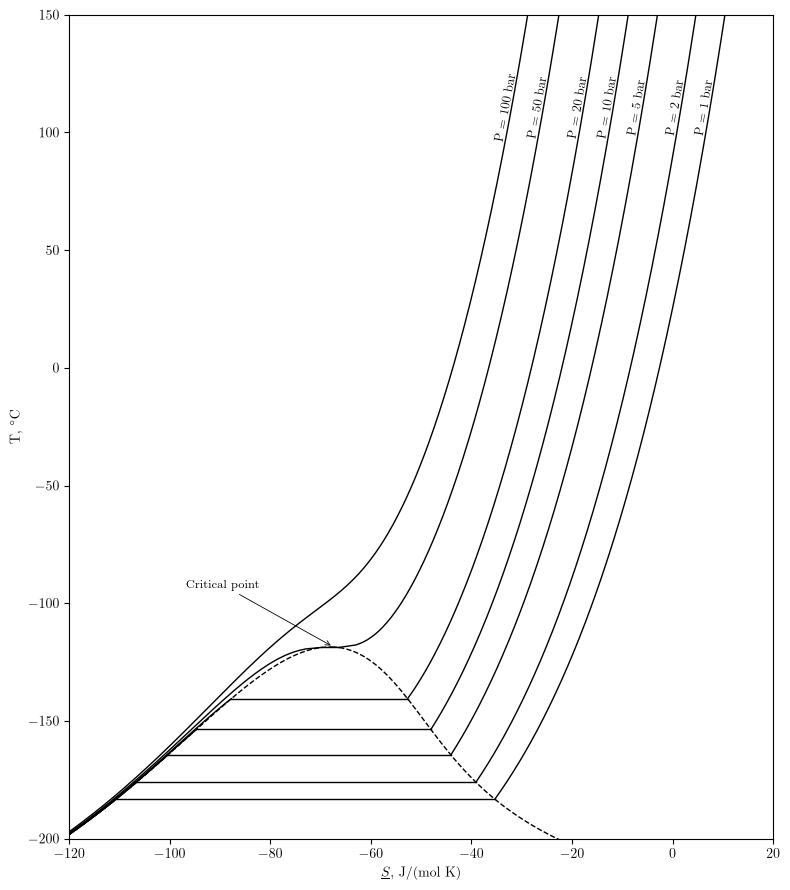

In [4]:
import os
import matplotlib as mpl
import matplotlib.pyplot as plt

# Typography, matching the recomputed figures in ch7 (Figs. 7.3-1 to 7.3-4, 7.5-2,
# 7.5-3): use a real LaTeX installation when there is one, so the figure is set in
# Computer Modern like the book, and fall back to matplotlib's own mathtext otherwise —
# the notebook still runs in Colab, which has no TeX.
from shutil import which

mpl.rcParams["text.usetex"] = which("latex") is not None
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",   # Computer Modern math for the no-TeX fallback
    "pdf.fonttype": 42,         # keep text as text in the PDF
    "ps.fonttype": 42,
})

fig, ax = plt.subplots(figsize=(8.0, 9.0))
BLACK = "black"

T_lo, T_hi = 63.0, 423.0   # K  (-210 C .. 150 C)
ax.set_xlim(-120, 20)
ax.set_ylim(-200, 150)


def S_branch(P, T_from, T_to, phase, n):
    T = np.linspace(T_from, T_to, n)
    return np.array([entropy(P, t, phase) for t in T]), T - TO_KELVIN


def slope_angle(P, T_K, phase):
    """On-screen angle (deg) of the vapor branch at temperature T_K, for labels."""
    s1 = entropy(P, T_K, phase);      p1 = ax.transData.transform((s1, T_K - TO_KELVIN))
    s2 = entropy(P, T_K + 2.0, phase); p2 = ax.transData.transform((s2, T_K + 2.0 - TO_KELVIN))
    return np.degrees(np.arctan2(p2[1] - p1[1], p2[0] - p1[0]))


for Pbar in [1, 2, 5, 10, 20, 50, 100]:
    P = Pbar * BAR
    if P >= Pc:                                  # supercritical single curve
        S, T = S_branch(P, T_lo, T_hi, "vapor", 400)
        ax.plot(S, T, "-", color=BLACK, lw=1)
    else:
        Ts = Tsat(P)
        Sl, Tl = S_branch(P, T_lo, Ts, "liquid", 150)
        Sv, Tv = S_branch(P, Ts, T_hi, "vapor", 250)
        ax.plot(Sl, Tl, "-", color=BLACK, lw=1)
        ax.plot(Sv, Tv, "-", color=BLACK, lw=1)
        ax.plot([SL_at(P), SV_at(P)], [Ts - TO_KELVIN, Ts - TO_KELVIN],
                "-", color=BLACK, lw=1)        # tie line
        # tie-line pressure label
        #ax.text(SL_at(P) - 2, Ts - TO_KELVIN, f"P = {Pbar} bar", fontsize=7.5,
        #        ha="right", va="center")

    # isobar label along the vapor branch, rotated to follow the curve
    T_lab = 110 + TO_KELVIN
    S_lab = entropy(P, T_lab, "vapor")
    ax.text(S_lab, T_lab - TO_KELVIN, f"P = {Pbar} bar", fontsize=9,
            rotation=slope_angle(P, T_lab, "vapor"), rotation_mode="anchor",
            ha="center", va="bottom")

# --- two-phase envelope + critical point ---
ax.plot(envelope.SL, envelope["T"] - TO_KELVIN, "--", color="black", lw=1)
ax.plot(envelope.SV, envelope["T"] - TO_KELVIN, "--", color="black", lw=1)
ax.annotate("Critical point",
            xy=(Sc, Tc - TO_KELVIN), xytext=(Sc - 22, Tc - TO_KELVIN + 25),
            fontsize=8.5, ha="center",
            arrowprops=dict(arrowstyle="->", lw=0.6, color=BLACK))

ax.set_xlabel("$\\underline{S}$, J/(mol K)")   # underbar S = molar entropy (book notation)
ax.set_ylabel("T, $^\\circ$C")

os.makedirs("pdf", exist_ok=True)
plt.tight_layout()
plt.savefig("pdf/Fig_6.4-5.pdf", dpi=300, bbox_inches="tight")
plt.show()
